# Exploratory Data Analysis of OKCupid Dating Profiles

This notebook explores demographic, lifestyle, and text-based patterns in OKCupid dating profiles.

The goal is to understand data quality, summarize key numerical and categorical features, identify potential outliers, and engineer a few simple features that may be useful for downstream ML tasks.

In [3]:
import pandas as pd;
import numpy as np;
import matplotlib.pyplot as plt;
from matplotlib.ticker import StrMethodFormatter;
from plot_style import set_plot_style

set_plot_style()

# Load Data

In [4]:
data_dir = "data/profiles.csv"

dat = pd.read_csv(data_dir)

# Dataset Overview

In [5]:
print(f"Number of rows: {dat.shape[0]:,}")
print(f"Number of columns: {dat.shape[1]}")
print("\nColumns:")
print(dat.columns.tolist())

print("\nData types:")
print(dat.dtypes)

print("\nFirst 5 rows:")
print(dat.head())

Number of rows: 59,946
Number of columns: 31

Columns:
['age', 'body_type', 'diet', 'drinks', 'drugs', 'education', 'essay0', 'essay1', 'essay2', 'essay3', 'essay4', 'essay5', 'essay6', 'essay7', 'essay8', 'essay9', 'ethnicity', 'height', 'income', 'job', 'last_online', 'location', 'offspring', 'orientation', 'pets', 'religion', 'sex', 'sign', 'smokes', 'speaks', 'status']

Data types:
age              int64
body_type          str
diet               str
drinks             str
drugs              str
education          str
essay0             str
essay1             str
essay2             str
essay3             str
essay4             str
essay5             str
essay6             str
essay7             str
essay8             str
essay9             str
ethnicity          str
height         float64
income           int64
job                str
last_online        str
location           str
offspring          str
orientation        str
pets               str
religion           str
sex          

In [6]:
(dat.head(1))

,age,body_type,diet,drinks,drugs,education,essay0,essay1,essay2,essay3,...,location,offspring,orientation,pets,religion,sex,sign,smokes,speaks,status
0,22,a little extra,strictly anything,socially,never,working on college/university,about me:<br />\n<br />\ni would love to think...,currently working as an international agent fo...,making people laugh.<br />\nranting about a go...,"the way i look. i am a six foot half asian, ha...",...,"south san francisco, california","doesn&rsquo;t have kids, but might want them",straight,likes dogs and likes cats,agnosticism and very serious about it,m,gemini,sometimes,english,single


# Missing Data Summary

In [7]:
overview = pd.DataFrame({
    "column": dat.columns,
    "dtype": dat.dtypes.values,
    "missing_count": dat.isnull().sum().values,
    "missing_percent": (dat.isnull().sum().values / len(dat) * 100).round(2)
})

overview = overview.sort_values("missing_percent", ascending=False)
overview


,column,dtype,missing_count,missing_percent
22,offspring,str,35561,59.32
2,diet,str,24395,40.69
25,religion,str,20226,33.74
24,pets,str,19921,33.23
14,essay8,str,19225,32.07
4,drugs,str,14080,23.49
12,essay6,str,13771,22.97
15,essay9,str,12603,21.02
13,essay7,str,12451,20.77
9,essay3,str,11476,19.14


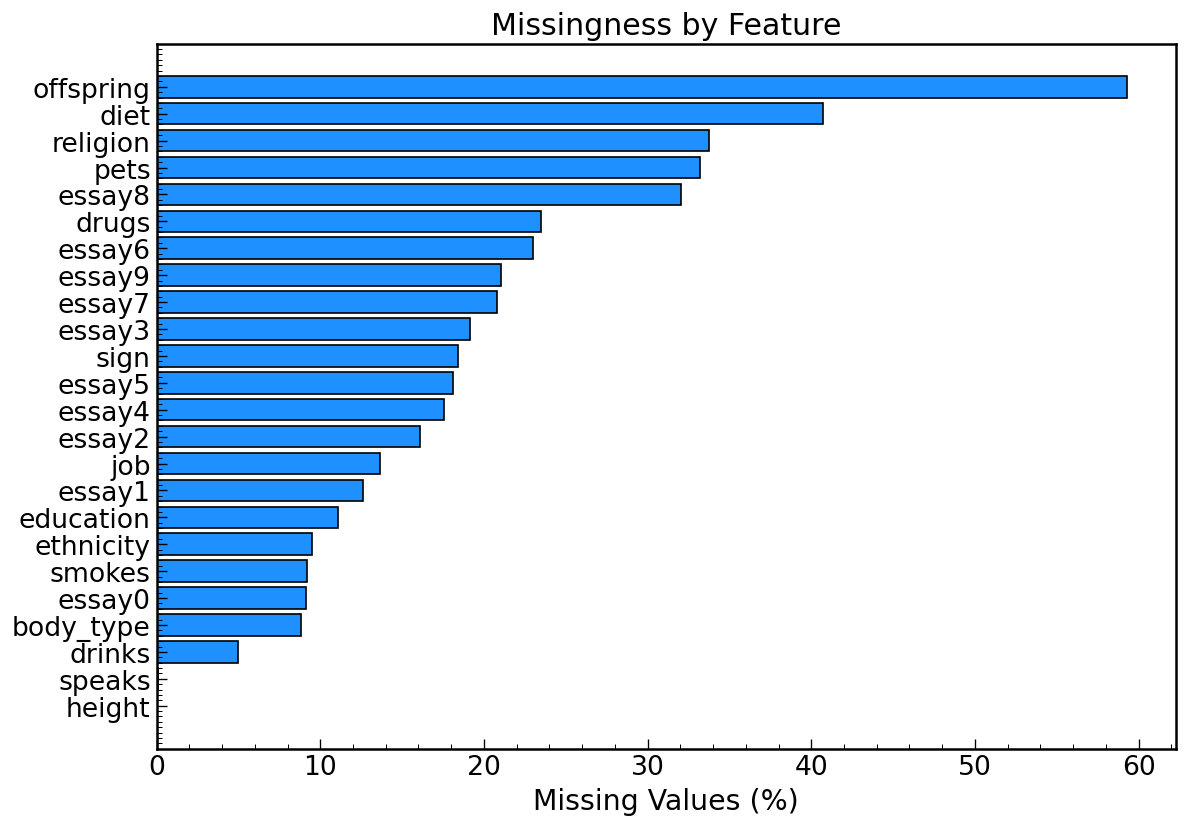

In [8]:
# Missingness by Feature -- Visualize the percentage of missing values for each feature.

missing_plot = overview[overview["missing_percent"] > 0].sort_values("missing_percent", ascending=True)

plt.figure(figsize=(10, 7))
plt.barh(
    missing_plot["column"],
    missing_plot["missing_percent"],
    edgecolor="black", color='dodgerblue'
)

plt.xlabel("Missing Values (%)")
plt.title("Missingness by Feature")
plt.tight_layout()
plt.show()


In [10]:
pct_missing = (dat['sign'].isnull().mean() * 100).round(1)
print(f"Sign column is missing for {pct_missing}% of users")

Sign column is missing for 18.4% of users


Notes: Several profile fields contain substantial missing data, with the most being "offspring". Several essay based responses are missing.

# Feature Cleaning and Simple Feature Engineering


In [51]:
dat["income_clean"] = dat["income"].where(dat["income"] > 0, np.nan)

essay_cols = [f"essay{i}" for i in range(10)]

dat["num_essays_filled"] = dat[essay_cols].notna().sum(axis=1)

dat["essay_total_length"] = dat[essay_cols].fillna("").apply(
    lambda row: sum(len(str(x)) for x in row), axis=1
)

dat["essay_avg_length"] = dat["essay_total_length"] / dat["num_essays_filled"].replace(0, np.nan)


# Numerical Summary Statistics

In [52]:
# Numerical Summary Statistics
num_summary = dat[["age", "height", "income_clean", "essay_total_length", "num_essays_filled"]].copy()

summary_table = num_summary.describe().T

summary_table = summary_table[
    ["count", "mean", "std", "min", "25%", "50%", "75%", "max"]
]

summary_table


,count,mean,std,min,25%,50%,75%,max
age,59946.0,32.340290,9.452779,18.0,26.0,30.0,37.00,110.0
height,59943.0,68.295281,3.994803,1.0,66.0,68.0,71.00,95.0
income_clean,11504.0,104394.993046,201433.528307,20000.0,20000.0,50000.0,100000.00,1000000.0
essay_total_length,59946.0,2200.076419,2021.455696,0.0,939.0,1777.0,2921.75,96268.0
num_essays_filled,59946.0,8.104778,2.798802,0.0,7.0,9.0,10.00,10.0


# Distributions of Numerical Features

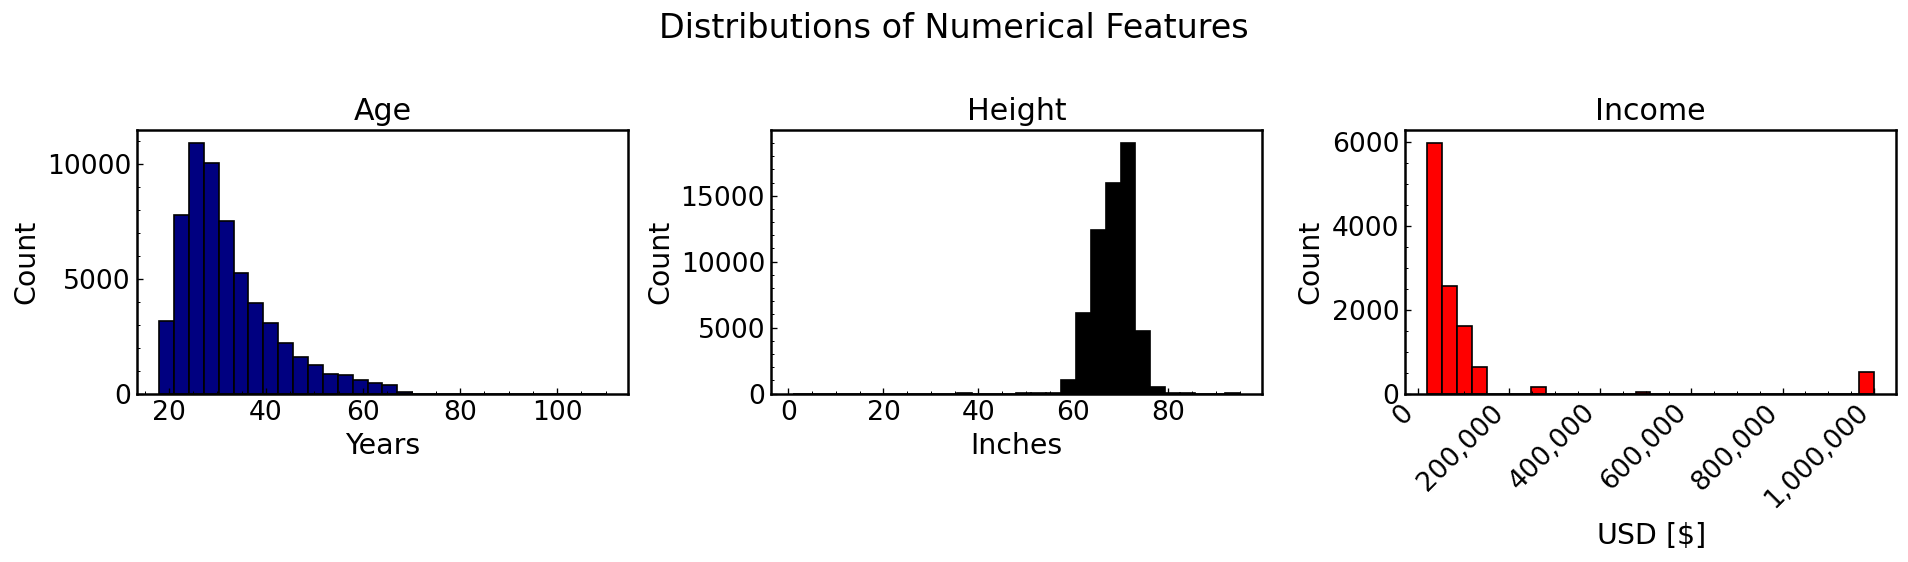

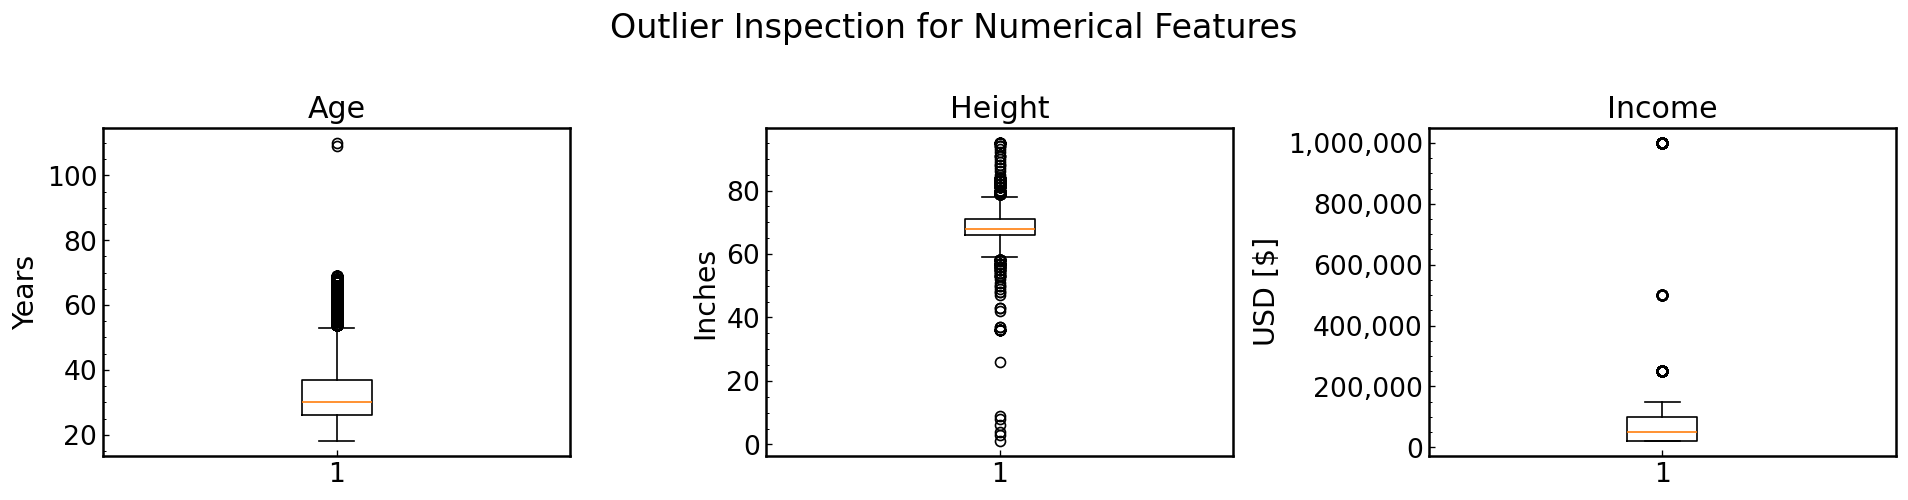

In [53]:
# Histogram of numerical variables

age = dat["age"].dropna()
height = dat["height"].dropna()
income = dat["income"].dropna()
income = income[income > 0] 

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

axes[0].hist(age, bins=30, color='navy', edgecolor="black")
axes[0].set_title("Age")
axes[0].set_xlabel("Years")
axes[0].set_ylabel("Count")

axes[1].hist(height, bins=30, color='k', edgecolor="black")
axes[1].set_title("Height")
axes[1].set_xlabel("Inches")
axes[1].set_ylabel("Count")

axes[2].hist(income, bins=30,color='r', edgecolor="black")
axes[2].set_title("Income")
axes[2].set_xlabel(r"USD [$\$$]")
axes[2].set_ylabel("Count")
axes[2].xaxis.set_major_formatter(StrMethodFormatter('{x:,.0f}'))
axes[2].tick_params(axis='x', labelrotation=45)
plt.setp(axes[2].get_xticklabels(), ha='right')

plt.suptitle("Distributions of Numerical Features", y=1.03, fontsize=20)
plt.tight_layout()
plt.show()


# Box plots of numerical variables

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].boxplot(age, vert=True)
axes[0].set_title("Age")
axes[0].set_ylabel("Years")

axes[1].boxplot(height, vert=True)
axes[1].set_title("Height")
axes[1].set_ylabel("Inches")

axes[2].boxplot(income, vert=True)
axes[2].set_title("Income")
axes[2].set_ylabel(r"USD [$\$$]")
axes[2].yaxis.set_major_formatter(StrMethodFormatter('{x:,.0f}'))

plt.suptitle("Outlier Inspection for Numerical Features", y=1.03, fontsize=20)
plt.tight_layout()
plt.show()


In [54]:
# clean summary statistics table

num_summary = dat[["age", "height", "income"]].copy()
num_summary["income"] = num_summary["income"].where(num_summary["income"] > 0, np.nan)

summary_table = num_summary.describe().T
summary_table


,count,mean,std,min,25%,50%,75%,max
age,59946.0,32.340290,9.452779,18.0,26.0,30.0,37.0,110.0
height,59943.0,68.295281,3.994803,1.0,66.0,68.0,71.0,95.0
income,11504.0,104394.993046,201433.528307,20000.0,20000.0,50000.0,100000.0,1000000.0


Notes: Median age is around 30 years old, the median height is around 68 inches, nad the median income is around $50,000. Age and height appear relatively concentrated, while income is strongly right-skewed. Income shows a much wider spread and more extreme outliers than age or height.


# Categorical Features

In [55]:
for col in ["sex", "orientation", "drinks", "smokes", "status", "job"]:
    print(f"\n--- {col.upper()} ---")
    print(dat[col].value_counts(dropna=False).head(10))



--- SEX ---
sex
m    35829
f    24117
Name: count, dtype: int64

--- ORIENTATION ---
orientation
straight    51606
gay          5573
bisexual     2767
Name: count, dtype: int64

--- DRINKS ---
drinks
socially       41780
rarely          5957
often           5164
not at all      3267
NaN             2985
very often       471
desperately      322
Name: count, dtype: int64

--- SMOKES ---
smokes
no                43896
NaN                5512
sometimes          3787
when drinking      3040
yes                2231
trying to quit     1480
Name: count, dtype: int64

--- STATUS ---
status
single            55697
seeing someone     2064
available          1865
married             310
unknown              10
Name: count, dtype: int64

--- JOB ---
job
NaN                               8198
other                             7589
student                           4882
science / tech / engineering      4848
computer / hardware / software    4709
artistic / musical / writer       4439
sales / marke

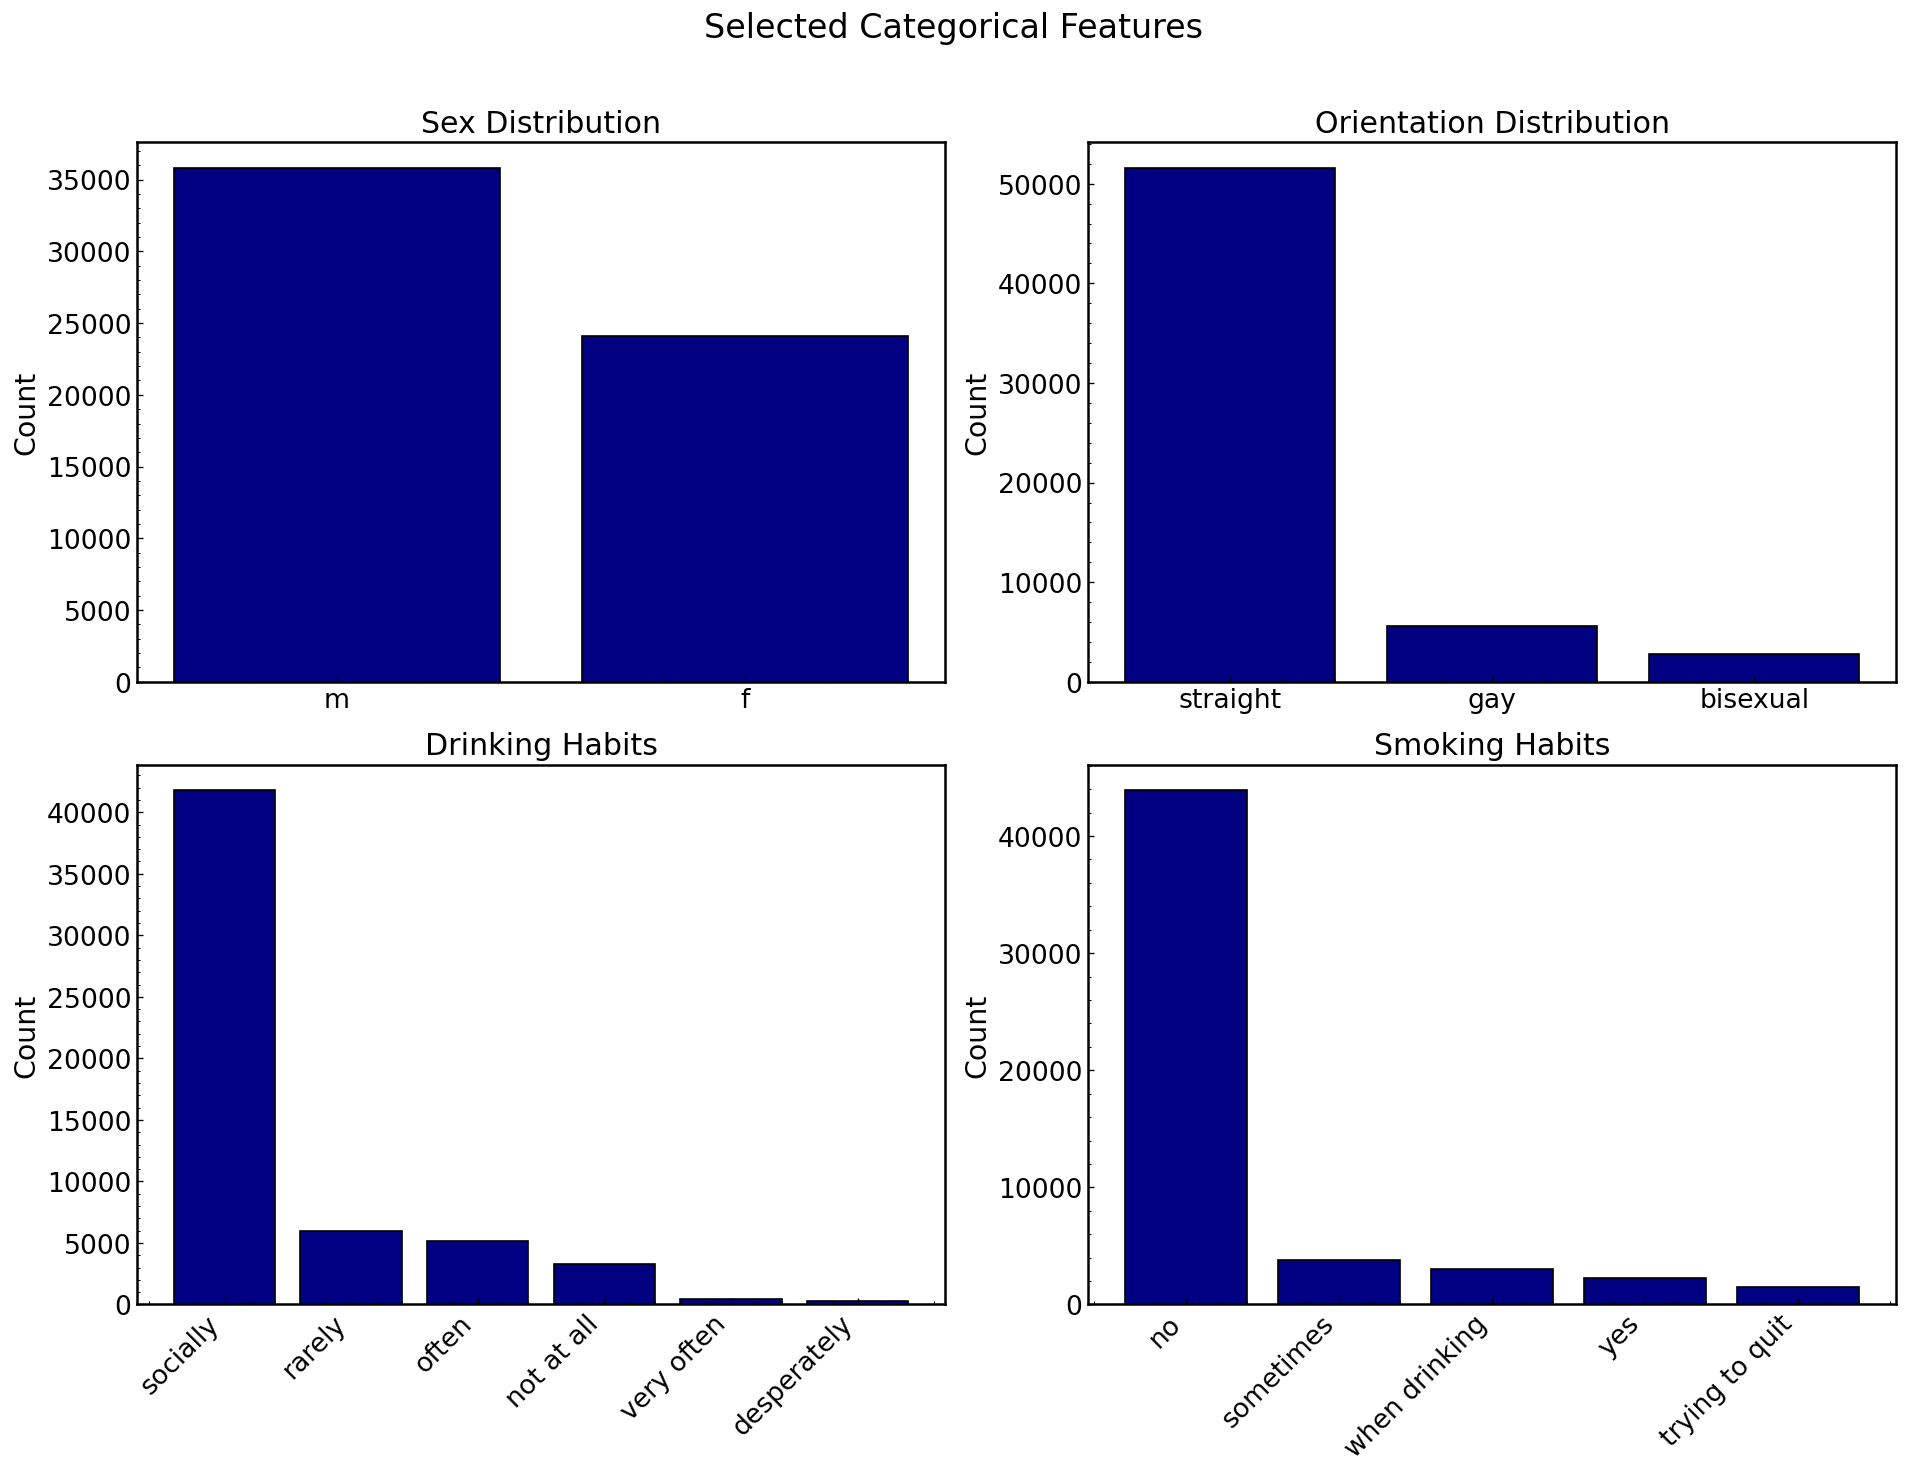

In [58]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

sex_counts = dat["sex"].value_counts()
axes[0, 0].bar(sex_counts.index, sex_counts.values, edgecolor="black", color='navy')
axes[0, 0].set_title("Sex Distribution")
axes[0, 0].set_ylabel("Count")

orientation_counts = dat["orientation"].value_counts()
axes[0, 1].bar(orientation_counts.index, orientation_counts.values, edgecolor="black", color='navy')
axes[0, 1].set_title("Orientation Distribution")
axes[0, 1].set_ylabel("Count")

drink_counts = dat["drinks"].value_counts()
axes[1, 0].bar(drink_counts.index, drink_counts.values, edgecolor="black", color='navy')
axes[1, 0].set_title("Drinking Habits")
axes[1, 0].set_ylabel("Count")
plt.setp(axes[1, 0].get_xticklabels(), rotation=45, ha="right")

smoke_counts = dat["smokes"].value_counts()
axes[1, 1].bar(smoke_counts.index, smoke_counts.values, edgecolor="black", color='navy')
axes[1, 1].set_title("Smoking Habits")
axes[1, 1].set_ylabel("Count")
plt.setp(axes[1, 1].get_xticklabels(), rotation=45, ha="right")

plt.suptitle("Selected Categorical Features", y=1.02, fontsize=20)
plt.tight_layout()
plt.show()


Notes: These distributions show that the dataset is not balanced across all categorical responses. This is useful to note because class imbalance may affect later classification tasks.


# Age Distribution by Sex

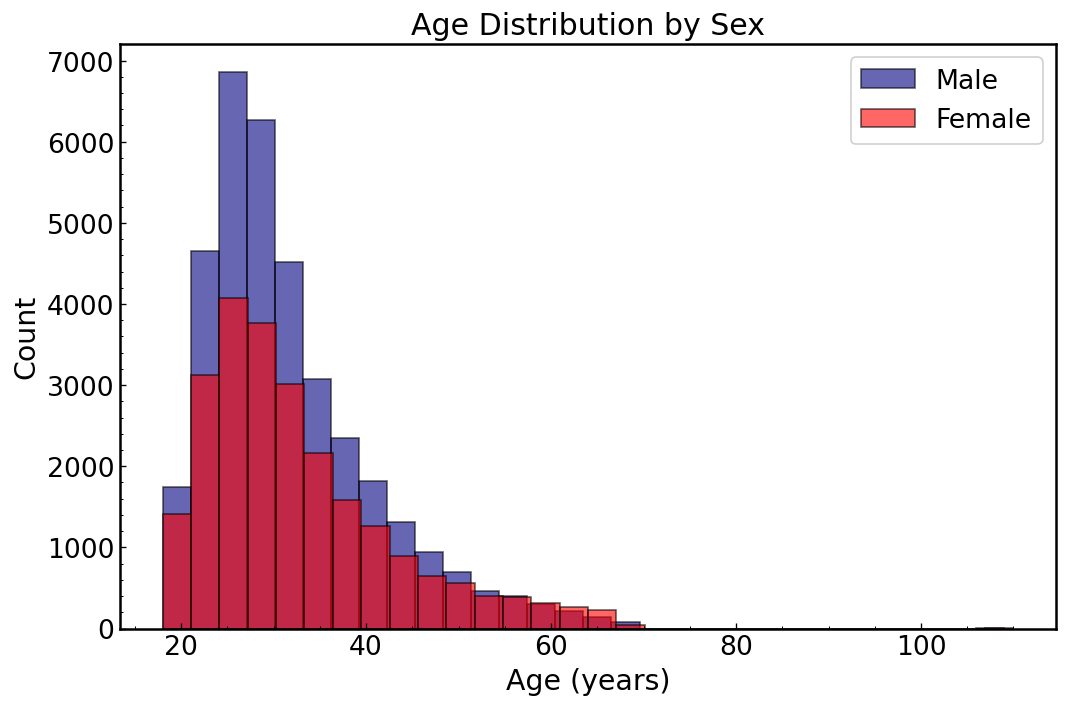

In [60]:
male_age = dat.loc[dat["sex"] == "m", "age"].dropna()
female_age = dat.loc[dat["sex"] == "f", "age"].dropna()

plt.figure(figsize=(9, 6))
plt.hist(male_age, bins=30, alpha=0.6, label="Male", edgecolor="black", color='navy')
plt.hist(female_age, bins=30, alpha=0.6, label="Female", edgecolor="black", color='r')

plt.xlabel("Age (years)")
plt.ylabel("Count")
plt.title("Age Distribution by Sex")
plt.legend()
plt.tight_layout()
plt.show()


# Age vs Height

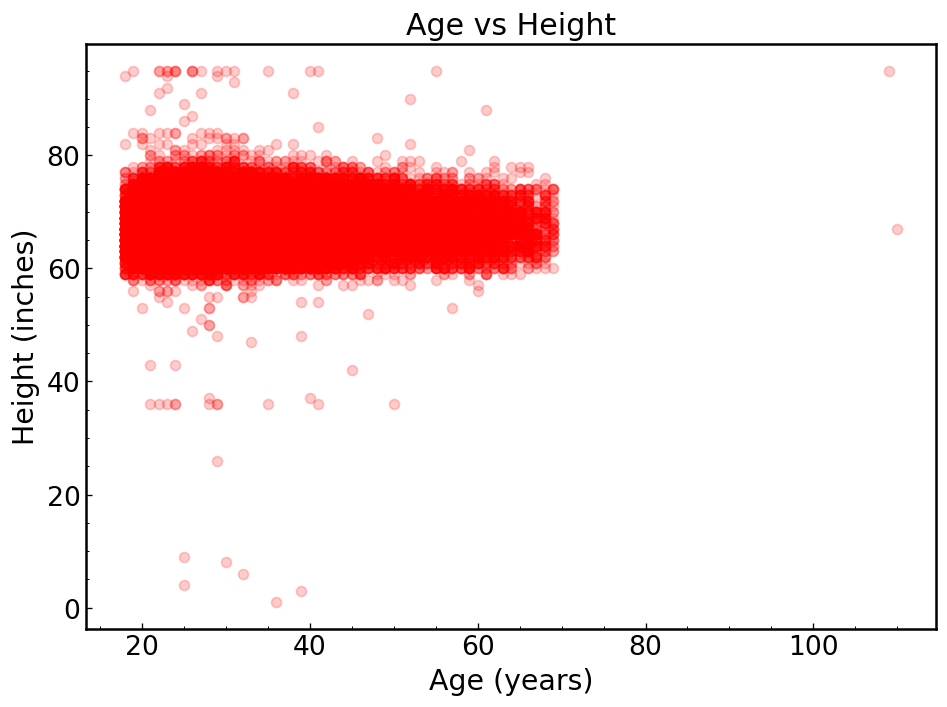

In [62]:
scatter_df = dat[["age", "height"]].dropna()

plt.figure(figsize=(8, 6))
plt.scatter(scatter_df["age"], scatter_df["height"], alpha=0.2, color='r')

plt.xlabel("Age (years)")
plt.ylabel("Height (inches)")
plt.title("Age vs Height")
plt.tight_layout()
plt.show()


# Age vs Total Essay Length

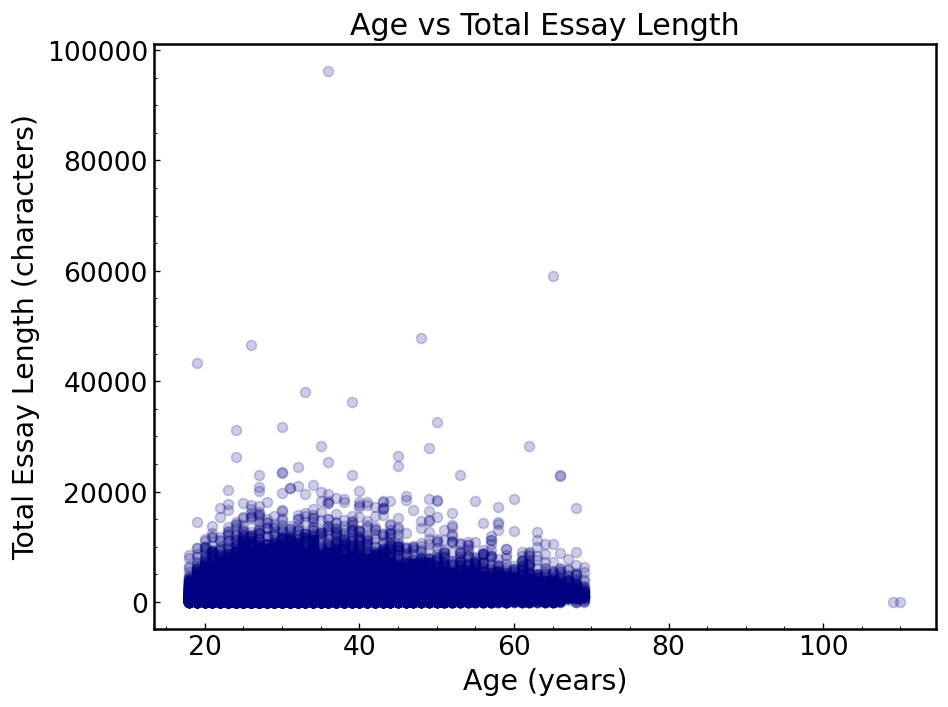

In [64]:
scatter_text_df = dat[["age", "essay_total_length"]].dropna()

plt.figure(figsize=(8, 6))
plt.scatter(scatter_text_df["age"], scatter_text_df["essay_total_length"], alpha=0.2, color='navy')

plt.xlabel("Age (years)")
plt.ylabel("Total Essay Length (characters)")
plt.title("Age vs Total Essay Length")
plt.tight_layout()
plt.show()


# Distribution of Total Essay Length

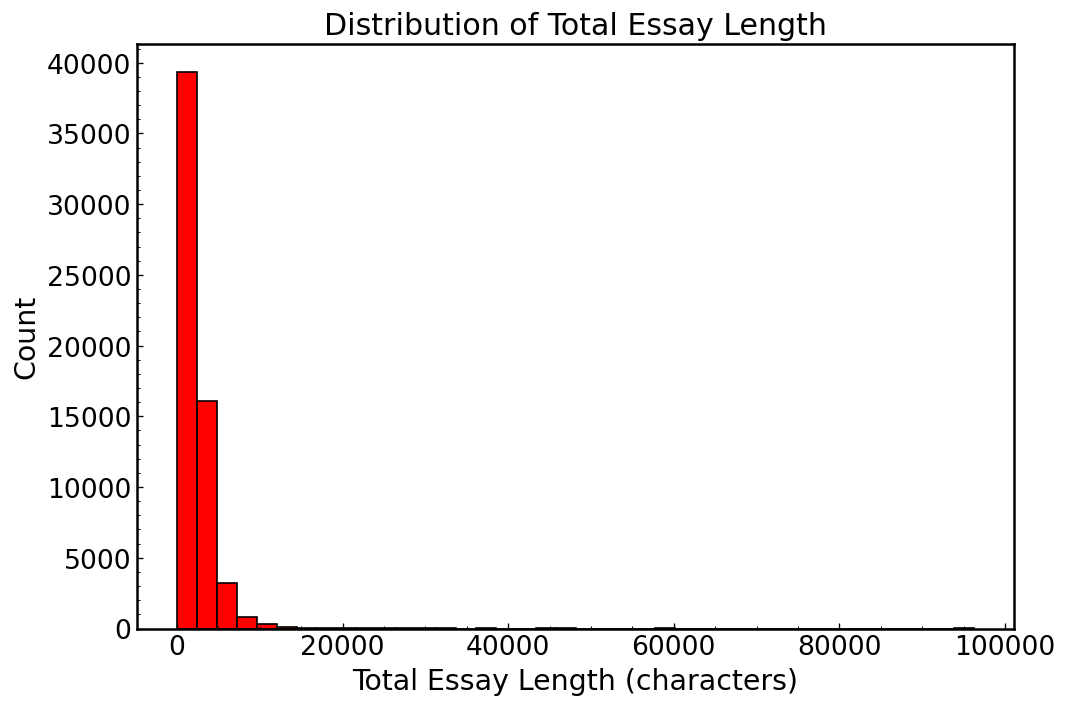

In [66]:
plt.figure(figsize=(9, 6))
plt.hist(dat["essay_total_length"], bins=40, edgecolor="black", color='r')

plt.xlabel("Total Essay Length (characters)")
plt.ylabel("Count")
plt.title("Distribution of Total Essay Length")
plt.tight_layout()
plt.show()


# Number of Essay Prompts Completed

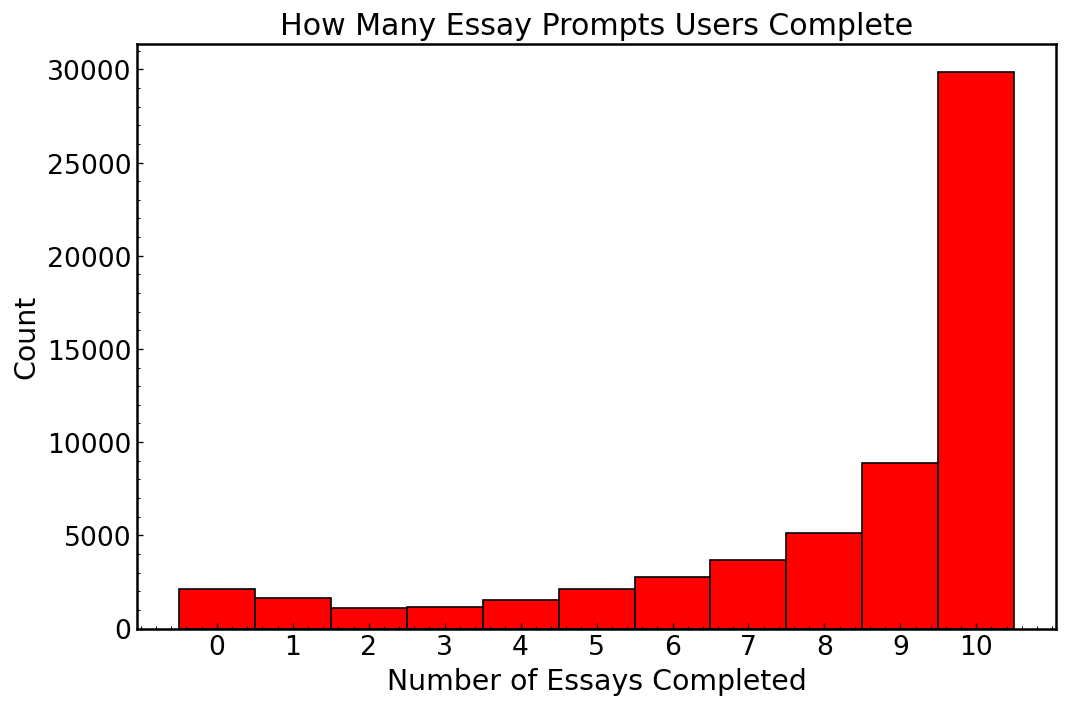

In [67]:
plt.figure(figsize=(9, 6))
plt.hist(dat["num_essays_filled"], bins=np.arange(-0.5, 11.5, 1), edgecolor="black", color='r')

plt.xlabel("Number of Essays Completed")
plt.ylabel("Count")
plt.title("How Many Essay Prompts Users Complete")
plt.xticks(range(0, 11))
plt.tight_layout()
plt.show()


# Smoking vs Drinking


In [68]:
ct = pd.crosstab(dat["smokes"], dat["drinks"])
ct

drinks,desperately,not at all,often,rarely,socially,very often
smokes,,,,,,
no,164,2771,2921,5080,31900,178
sometimes,35,159,603,311,2563,61
trying to quit,21,114,217,151,928,20
when drinking,33,13,482,119,2314,57
yes,36,149,570,165,1140,127


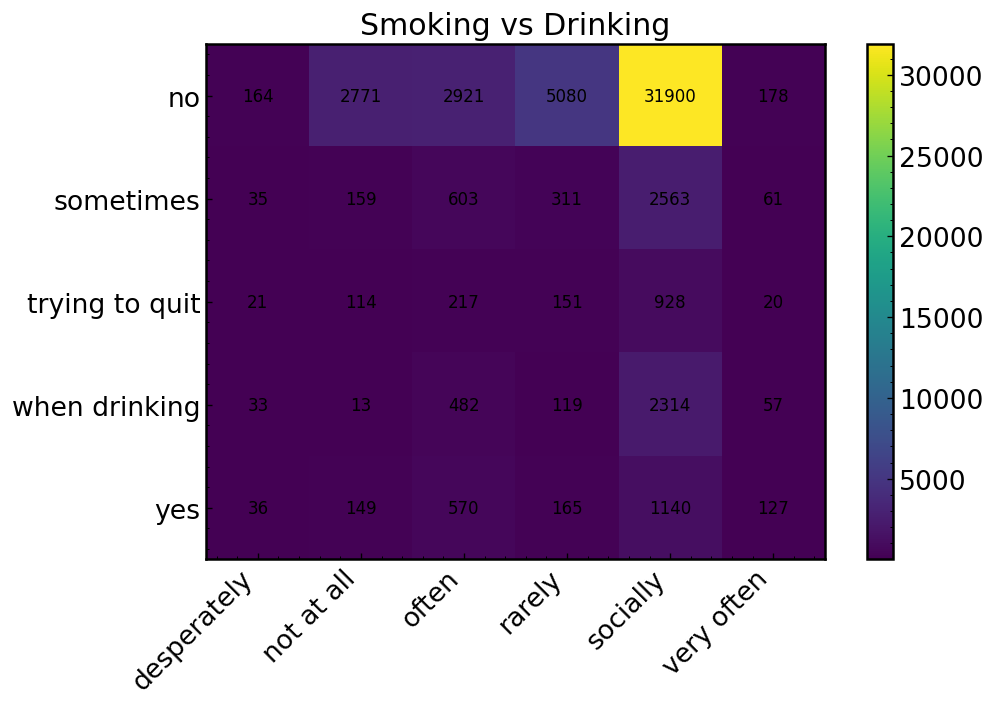

In [77]:
fig, ax = plt.subplots(figsize=(9, 6))
im = ax.imshow(ct.values, cmap="viridis")

ax.set_xticks(np.arange(len(ct.columns)))
ax.set_yticks(np.arange(len(ct.index)))
ax.set_xticklabels(ct.columns, rotation=45, ha="right")
ax.set_yticklabels(ct.index)

for i in range(ct.shape[0]):
    for j in range(ct.shape[1]):
        ax.text(j, i, ct.iloc[i, j], ha="center", va="center", fontsize=10)

plt.colorbar(im, ax=ax)
plt.title("Smoking vs Drinking")
plt.tight_layout()
plt.show()


# Correlation Matrix

In [78]:
corr_df = dat[[
    "age",
    "height",
    "income_clean",
    "essay_total_length",
    "num_essays_filled",
    "essay_avg_length"
]].copy()

corr = corr_df.corr(numeric_only=True)
corr


,age,height,income_clean,essay_total_length,num_essays_filled,essay_avg_length
age,1.000000,-0.022262,-0.009234,0.078647,0.014811,0.096323
height,-0.022262,1.000000,0.058829,0.010399,-0.000223,0.010623
income_clean,-0.009234,0.058829,1.000000,0.002646,0.016487,-0.003176
essay_total_length,0.078647,0.010399,0.002646,1.000000,0.418735,0.819292
num_essays_filled,0.014811,-0.000223,0.016487,0.418735,1.000000,0.019602
essay_avg_length,0.096323,0.010623,-0.003176,0.819292,0.019602,1.000000


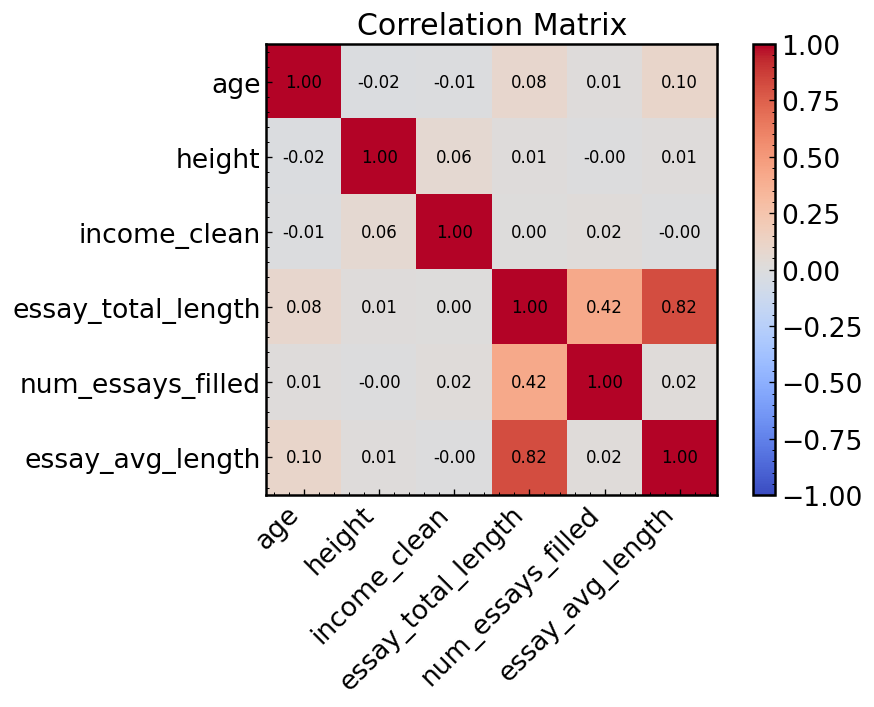

In [79]:
fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)

ax.set_xticks(np.arange(len(corr.columns)))
ax.set_yticks(np.arange(len(corr.columns)))
ax.set_xticklabels(corr.columns, rotation=45, ha="right")
ax.set_yticklabels(corr.columns)

for i in range(len(corr.columns)):
    for j in range(len(corr.columns)):
        val = corr.iloc[i, j]
        if pd.notnull(val):
            ax.text(j, i, f"{val:.2f}", ha="center", va="center", fontsize=10)

plt.colorbar(im, ax=ax)
plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()


In [83]:
corr_df = dat[[
    "age",
    "height",
    "income_clean",
    "essay_total_length",
    "num_essays_filled",
    "essay_avg_length"
]].copy()


In [84]:
dat["is_male"] = (dat["sex"] == "m").astype(int)

dat["smokes_binary"] = dat["smokes"].isin(["yes", "sometimes"]).astype(int)

dat["drinks_binary"] = dat["drinks"].isin(["often", "very often", "socially"]).astype(int)

corr_df = dat[[
    "age",
    "height",
    "income_clean",
    "essay_total_length",
    "num_essays_filled",
    "essay_avg_length",
    "is_male",
    "smokes_binary",
    "drinks_binary"
]]

orientation_dummies = pd.get_dummies(dat["orientation"], prefix="orientation")

corr_df = pd.concat([
    corr_df,
    orientation_dummies
], axis=1)

corr = corr_df.corr()


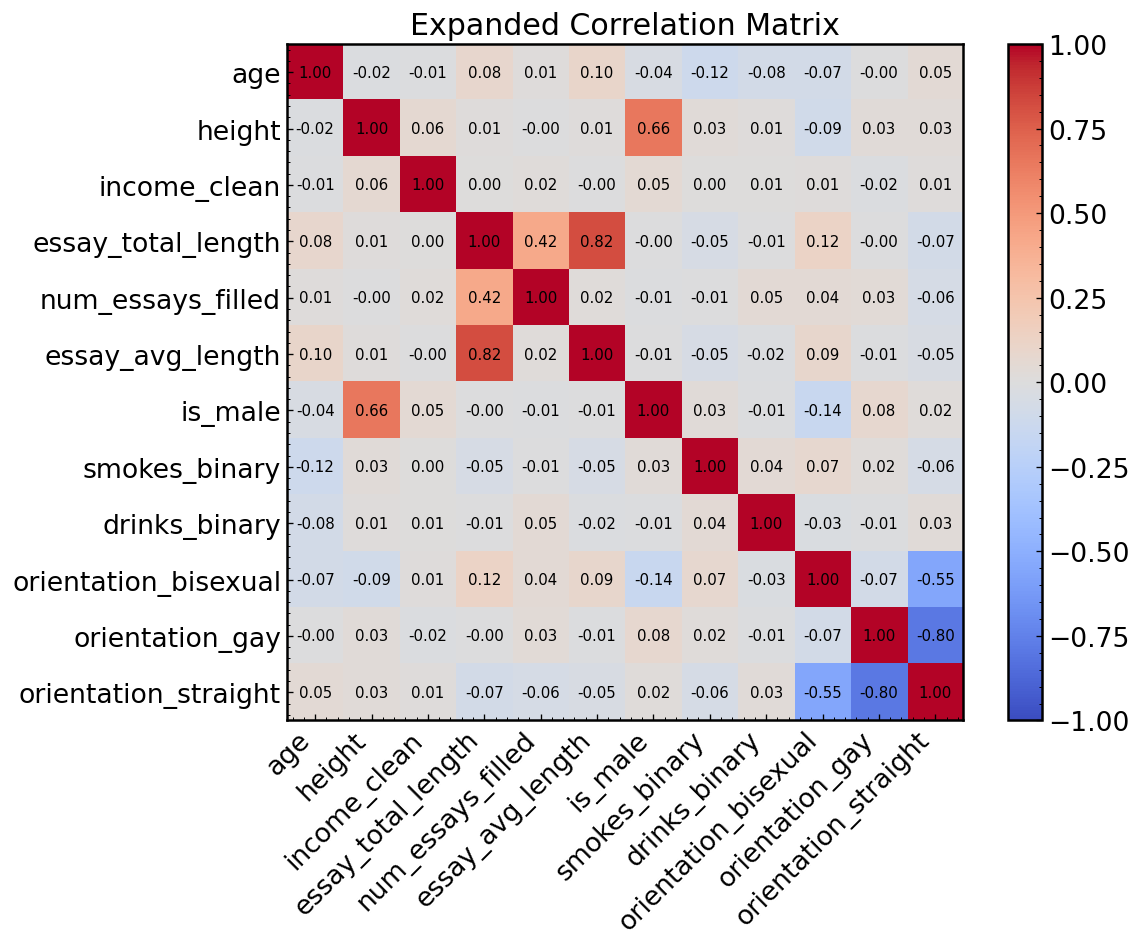

In [85]:
fig, ax = plt.subplots(figsize=(10, 8))

im = ax.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)

ax.set_xticks(np.arange(len(corr.columns)))
ax.set_yticks(np.arange(len(corr.columns)))
ax.set_xticklabels(corr.columns, rotation=45, ha="right")
ax.set_yticklabels(corr.columns)

for i in range(len(corr.columns)):
    for j in range(len(corr.columns)):
        val = corr.iloc[i, j]
        if pd.notnull(val):
            ax.text(j, i, f"{val:.2f}", ha="center", va="center", fontsize=9)

plt.colorbar(im, ax=ax)

plt.title("Expanded Correlation Matrix")

plt.tight_layout()
plt.show()


## Key Findings

- The dataset contains a mix of demographic, lifestyle, and text-based profile information.
- Several optional fields have substantial missing values, especially essay and family-related variables.
- Age is concentrated among younger adult users (~30 years old), while income is strongly right-skewed and contains extreme values.
- Categorical variables such as drinking and smoking are unevenly distributed.